In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
 
from sklearn.preprocessing import RobustScaler


In [3]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [4]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [5]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [6]:
# Check null values in D3
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [7]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [8]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [9]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [10]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [11]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [12]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [13]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [14]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [15]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [16]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [17]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Standardization for Clustering

In [18]:
original_X = X.copy()

In [19]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
scaler = RobustScaler()  
X_numeric_std = scaler.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

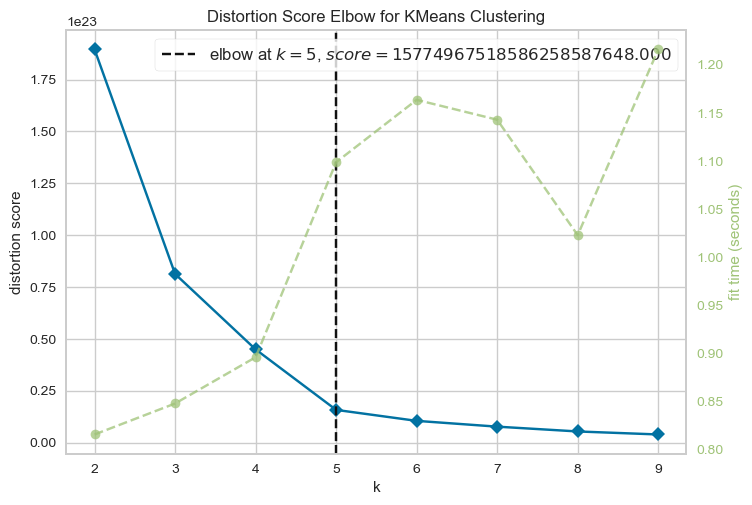

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# How many clusters to form - 1. Using elbow method 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [21]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: glszm_LargeAreaLowGrayLevelEmphasis_CT_c16
Correlation coefficient: 70.1247383577268


1
Most correlated column: glszm_LargeAreaLowGrayLevelEmphasis_PET_c04
Correlation coefficient: 5087.237820106097


2
Most correlated column: glszm_LargeAreaLowGrayLevelEmphasis_PET_b2
Correlation coefficient: 1055.19167151558


3
Most correlated column: glcm_ClusterShade_d_1_CT_b20
Correlation coefficient: 34.76129123954451


4
Most correlated column: gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
Correlation coefficient: 46.818339041452326




In [22]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [23]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [24]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [25]:
X_new

,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glcm_ClusterShade_d_1_CT_b20,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
0,7442.066260,879096.343994,2.625216e+05,-298.895100,0.056560
1,238.870676,26566.901706,1.242203e+05,-535.365447,0.095346
2,12957.157420,647295.586841,2.397332e+06,-1376.524977,0.052264
3,233.632355,40145.962374,1.252457e+06,-847.392287,0.027762
4,121.921768,10927.978256,1.366458e+05,-1188.023474,0.034148
...,...,...,...,...,...
134,1528.464999,215024.891557,4.128076e+05,8.640931,0.176183
135,41182.958565,338158.975184,3.892908e+06,-686.754900,0.148848
136,3964.057173,974304.249507,1.734434e+05,-948.768231,0.130961
137,5243.112516,199030.525466,1.164868e+06,-90.384402,0.258550


In [26]:
X_new_std

,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glcm_ClusterShade_d_1_CT_b20,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
0,0.233483,0.627985,-0.165378,0.296721,-0.473236
1,-0.164858,-0.249270,-0.309221,0.122953,-0.033964
2,0.538471,0.389462,2.054971,-0.495167,-0.521881
3,-0.165148,-0.235297,0.864223,-0.106338,-0.799374
4,-0.171326,-0.265362,-0.296297,-0.356648,-0.727051
...,...,...,...,...,...
134,-0.093543,-0.055346,-0.009070,0.522711,0.881543
135,2.099375,0.071360,3.610473,0.011705,0.571968
136,0.041147,0.725955,-0.258025,-0.180833,0.369390
137,0.111879,-0.071804,0.773124,0.449943,1.814381


In [27]:
MAASTRO_new

,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glcm_ClusterShade_d_1_CT_b20,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
0,9404.025346,1.125054e+06,3.686456e+05,-334.546058,0.203608
1,16468.863361,1.948450e+06,2.114589e+06,-6216.225223,0.077923
2,3829.811759,1.403912e+06,4.579214e+05,-1732.064419,0.119332
3,2212.056593,4.555744e+05,9.121242e+05,-21920.694268,1.487269
4,20185.616389,8.660429e+05,3.260921e+06,-235.807498,0.129126
...,...,...,...,...,...
94,18006.593217,9.500595e+05,5.034748e+04,319.664572,0.097901
95,1303.136099,3.718008e+06,8.736992e+05,-19066.639918,0.135426
96,8928.353080,2.726200e+06,7.999319e+06,-997.961427,0.083343
97,13835.684015,2.138315e+06,6.943470e+05,-37.054161,0.071296


In [28]:
MAASTRO_new_std

,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glcm_ClusterShade_d_1_CT_b20,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
0,0.341981,0.881077,-0.055002,0.270523,1.192147
1,0.732670,1.728353,1.760899,-4.051583,-0.231290
2,0.033723,1.168022,0.037851,-0.756432,0.237686
3,-0.055740,0.192180,0.510253,-15.591890,15.730108
4,0.938209,0.614553,2.953163,0.343080,0.348610
...,...,...,...,...,...
94,0.817708,0.701007,-0.386054,0.751265,-0.005024
95,-0.106004,3.549233,0.470289,-13.494610,0.419960
96,0.315676,2.528660,7.881422,-0.216982,-0.169908
97,0.587054,1.923725,0.283750,0.489133,-0.306341


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [29]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-18 16:01:23,277] A new study created in memory with name: no-name-aff7a2f6-144c-480e-9d66-103724b67520


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.4581673306772908
Fold 2 C-index: 0.627906976744186
Fold 3 C-index: 0.7829787234042553


[I 2024-04-18 16:01:24,530] A new study created in memory with name: no-name-1c00560e-50ce-4a30-8479-f619731e82bf


Fold 4 C-index: 0.41064638783269963
Fold 5 C-index: 0.4592274678111588
[I 2024-04-18 16:01:24,520] Trial 0 finished with value: 0.5477853772939182 and parameters: {}. Best is trial 0 with value: 0.5477853772939182.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5477853772939182], datetime_start=datetime.datetime(2024, 4, 18, 16, 1, 23, 518995), datetime_complete=datetime.datetime(2024, 4, 18, 16, 1, 24, 519991), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5477853772939182


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2500638670551152
Fold 2 IBS: 0.22052189250114246
Fold 3 IBS: 0.1955338513105058
Fold 4 IBS: 0.28626756840824175
Fold 5 IBS: 0.23059032904925117
[I 2024-04-18 16:01:25,396] Trial 0 finished with value: 0.23659550166485127 and parameters: {}. Best is trial 0 with value: 0.23659550166485127.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23659550166485127], datetime_start=datetime.datetime(2024, 4, 18, 16, 1, 24, 555663), datetime_complete=datetime.datetime(2024, 4, 18, 16, 1, 25, 395711), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23659550166485127


In [30]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [31]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.548
train_ibs:  0.237


#### Test

In [32]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [33]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.533
IBS score: 0.239


In [34]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [35]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [36]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 16:01:25,880] A new study created in memory with name: no-name-e4d16cd3-be22-4dbb-856d-fc3f0777fcc6


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6608527131782945
Fold 3 C-index: 0.7212765957446808
Fold 4 C-index: 0.5456273764258555


[I 2024-04-18 16:01:26,355] A new study created in memory with name: no-name-32e1b1f2-1ea6-46ce-a8a0-14f57e910f08


Fold 5 C-index: 0.5236051502145923
[I 2024-04-18 16:01:26,276] Trial 0 finished with value: 0.5747345185071069 and parameters: {}. Best is trial 0 with value: 0.5747345185071069.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5747345185071069], datetime_start=datetime.datetime(2024, 4, 18, 16, 1, 25, 920422), datetime_complete=datetime.datetime(2024, 4, 18, 16, 1, 26, 275750), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5747345185071069


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724711869367466
Fold 2 IBS: 0.23203987663984238
Fold 3 IBS: 0.22898184031034338
Fold 4 IBS: 0.24197479107544392
Fold 5 IBS: 0.22939559003281138
[I 2024-04-18 16:01:26,909] Trial 0 finished with value: 0.23592784335042313 and parameters: {}. Best is trial 0 with value: 0.23592784335042313.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784335042313], datetime_start=datetime.datetime(2024, 4, 18, 16, 1, 26, 403778), datetime_complete=datetime.datetime(2024, 4, 18, 16, 1, 26, 909377), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784335042313


In [37]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [38]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.575
train_ibs:  0.236


#### Test

In [39]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [40]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.559


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [41]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [42]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 16:01:27,335] A new study created in memory with name: no-name-89122bcb-4d81-45b8-bc39-5543528fca38


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.532319391634981


[I 2024-04-18 16:01:27,797] A new study created in memory with name: no-name-37a33cee-7546-478b-b038-1d52a566fab8


Fold 5 C-index: 0.48068669527896996
[I 2024-04-18 16:01:27,788] Trial 0 finished with value: 0.5712791035619725 and parameters: {}. Best is trial 0 with value: 0.5712791035619725.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5712791035619725], datetime_start=datetime.datetime(2024, 4, 18, 16, 1, 27, 388372), datetime_complete=datetime.datetime(2024, 4, 18, 16, 1, 27, 788349), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5712791035619725


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2475597546840513
Fold 2 IBS: 0.2319284672546224
Fold 3 IBS: 0.22676973830629266
Fold 4 IBS: 0.24225811304237807
Fold 5 IBS: 0.22931739699661338
[I 2024-04-18 16:01:28,380] Trial 0 finished with value: 0.2355666940567916 and parameters: {}. Best is trial 0 with value: 0.2355666940567916.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2355666940567916], datetime_start=datetime.datetime(2024, 4, 18, 16, 1, 27, 875751), datetime_complete=datetime.datetime(2024, 4, 18, 16, 1, 28, 380673), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2355666940567916


In [43]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [44]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.571
train_ibs:  0.236


#### Test

In [45]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [46]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.562


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.229


In [47]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [48]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 16:01:28,988] A new study created in memory with name: no-name-9053c55c-0f0c-4faf-b859-e1eb92410501


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-18 16:01:29,445] Trial 0 finished with value: 0.5712791035619725 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5712791035619725.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-18 16:01:29,931] Trial 1 finished with value: 0.5712791035619725 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.5712791035619725.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-18 16:01:30,359] Trial 2 finished with value: 0.5712791035619725 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-18 16:01:38,966] Trial 24 finished with value: 0.5712791035619725 and parameters: {'l1_ratio': 0.15433706302991543}. Best is trial 0 with value: 0.5712791035619725.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-18 16:01:39,297] Trial 25 finished with value: 0.5712791035619725 and parameters: {'l1_ratio': 0.4626599986704694}. Best is trial 0 with value: 0.5712791035619725.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-18 16:01:39,677] Trial 26 finished with value: 0.5712791035619725 and parameters: {'l1_ratio': 0.3312072877416866}. Best is trial 0 with value: 0.5712791035619725.
Fold 1 C-index: 0.42

Fold 3 C-index: 0.7276595744680852
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-18 16:01:46,719] Trial 48 finished with value: 0.5721301673917598 and parameters: {'l1_ratio': 0.051930691288236505}. Best is trial 27 with value: 0.5721301673917598.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-18 16:01:47,038] Trial 49 finished with value: 0.5712791035619725 and parameters: {'l1_ratio': 0.2196761365683986}. Best is trial 27 with value: 0.5721301673917598.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-18 16:01:47,343] Trial 50 finished with value: 0.5712791035619725 and parameters: {'l1_ratio': 0.31297686520002327}. Best is trial 27 with value: 0.5721301673917598.
Fold 1 C-index

...

Fold 1 IBS: 0.24755958760346264
Fold 2 IBS: 0.23192851633610806
Fold 3 IBS: 0.2267808928937214
Fold 4 IBS: 0.2422579788616089
Fold 5 IBS: 0.22931745839964415
[I 2024-04-18 16:02:06,289] Trial 0 finished with value: 0.23556888681890903 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.23556888681890903.
Fold 1 IBS: 0.24755880017840598
Fold 2 IBS: 0.23192874780402192
Fold 3 IBS: 0.22683205478753657
Fold 4 IBS: 0.24225734635274424
Fold 5 IBS: 0.22931774748923892
[I 2024-04-18 16:02:06,773] Trial 1 finished with value: 0.2355789393223895 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.23556888681890903.
Fold 1 IBS: 0.2475584518990552
Fold 2 IBS: 0.23192885026387583
Fold 3 IBS: 0.2268539704337813
Fold 4 IBS: 0.24225706652157003
Fold 5 IBS: 0.22931787519940183
[I 2024-04-18 16:02:07,629] Trial 2 finished with value: 0.23558324286353685 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.23556888681890

Fold 2 IBS: 0.23192847831329896
Fold 3 IBS: 0.22677226117996752
Fold 4 IBS: 0.24225808280790104
Fold 5 IBS: 0.2293174108346429
[I 2024-04-18 16:02:19,265] Trial 25 finished with value: 0.2355671900342184 and parameters: {'l1_ratio': 0.9106143729430608}. Best is trial 11 with value: 0.23556670811822.
Fold 1 IBS: 0.24755962115403868
Fold 2 IBS: 0.23192850647939173
Fold 3 IBS: 0.22677866159598728
Fold 4 IBS: 0.242258005806552
Fold 5 IBS: 0.2293174460713714
[I 2024-04-18 16:02:19,719] Trial 26 finished with value: 0.23556844822146822 and parameters: {'l1_ratio': 0.7417169602645222}. Best is trial 11 with value: 0.23556670811822.
Fold 1 IBS: 0.24755954776141212
Fold 2 IBS: 0.2319285280417777
Fold 3 IBS: 0.2267835370325359
Fold 4 IBS: 0.24225794686336652
Fold 5 IBS: 0.22931747303859967
[I 2024-04-18 16:02:20,134] Trial 27 finished with value: 0.23556940654753838 and parameters: {'l1_ratio': 0.6494728799686162}. Best is trial 11 with value: 0.23556670811822.
Fold 1 IBS: 0.24755968194202913
Fo

Fold 1 IBS: 0.24755970171191305
Fold 2 IBS: 0.23192848281444092
Fold 3 IBS: 0.226773286443661
Fold 4 IBS: 0.24225807050206635
Fold 5 IBS: 0.2293174164665217
[I 2024-04-18 16:02:33,945] Trial 50 finished with value: 0.23556739158772064 and parameters: {'l1_ratio': 0.8786447363305766}. Best is trial 40 with value: 0.23556669513229425.
Fold 1 IBS: 0.2475597342897883
Fold 2 IBS: 0.23192847324501292
Fold 3 IBS: 0.22677110562200428
Fold 4 IBS: 0.24225809666448592
Fold 5 IBS: 0.22931740449278343
[I 2024-04-18 16:02:34,609] Trial 51 finished with value: 0.23556696286281498 and parameters: {'l1_ratio': 0.9495136153828908}. Best is trial 40 with value: 0.23556669513229425.
Fold 1 IBS: 0.24755973687897778
Fold 2 IBS: 0.23192847248448295
Fold 3 IBS: 0.22677093212118699
Fold 4 IBS: 0.2422580987437783
Fold 5 IBS: 0.229317403541112
[I 2024-04-18 16:02:35,207] Trial 52 finished with value: 0.23556692875390764 and parameters: {'l1_ratio': 0.9556391205035538}. Best is trial 40 with value: 0.235566695132

Fold 5 IBS: 0.22931739713182533
[I 2024-04-18 16:02:47,049] Trial 74 finished with value: 0.23556669890812207 and parameters: {'l1_ratio': 0.9990419168427266}. Best is trial 40 with value: 0.23556669513229425.
Fold 1 IBS: 0.2475597227880232
Fold 2 IBS: 0.23192847662349264
Fold 3 IBS: 0.22677187603873444
Fold 4 IBS: 0.2422580874277699
Fold 5 IBS: 0.22931740872026005
[I 2024-04-18 16:02:47,685] Trial 75 finished with value: 0.23556711431965605 and parameters: {'l1_ratio': 0.9232248440809541}. Best is trial 40 with value: 0.23556669513229425.
Fold 1 IBS: 0.24755974175451345
Fold 2 IBS: 0.23192847105238537
Fold 3 IBS: 0.22677060534263846
Fold 4 IBS: 0.2422581026591531
Fold 5 IBS: 0.22931740174906667
[I 2024-04-18 16:02:48,247] Trial 76 finished with value: 0.2355668645115514 and parameters: {'l1_ratio': 0.9673906281038791}. Best is trial 40 with value: 0.23556669513229425.
Fold 1 IBS: 0.2475597113083937
Fold 2 IBS: 0.23192847999552454
Fold 3 IBS: 0.22677264446345377
Fold 4 IBS: 0.242258078

Fold 2 IBS: 0.23192847139555578
Fold 3 IBS: 0.22677068365644196
Fold 4 IBS: 0.2422581017209188
Fold 5 IBS: 0.22931740217849336
[I 2024-04-18 16:03:00,965] Trial 99 finished with value: 0.2355668799075213 and parameters: {'l1_ratio': 0.964548404109892}. Best is trial 40 with value: 0.23556669513229425.


* Best trial for IBS: 
 FrozenTrial(number=40, state=TrialState.COMPLETE, values=[0.23556669513229425], datetime_start=datetime.datetime(2024, 4, 18, 16, 2, 27, 2086), datetime_complete=datetime.datetime(2024, 4, 18, 16, 2, 27, 530575), params={'l1_ratio': 0.9997874437591321}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=40, value=None)


* Best Score for IBS: 
 0.23556669513229425


In [49]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [50]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.572
train_ibs:  0.236


#### Test

In [51]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [52]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.09486155085202524)

test_cindex : 0.562


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.9997874437591321)

test_ibs:  0.229


In [53]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [54]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-18 16:03:01,335] A new study created in memory with name: no-name-065b786c-e078-49a5-8dde-9e12e6459fd1


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.41832669322709165
Fold 2 C-index: 0.627906976744186
Fold 3 C-index: 0.5106382978723404
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.5021459227467812
[I 2024-04-18 16:03:14,816] Trial 0 finished with value: 0.509141981159905 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.509141981159905.
Fold 1 C-index: 0.41434262948207173
Fold 2 C-index: 0.6201550387596899
Fold 3 C-index: 0.4808510638297872
Fold 4 C-index: 0.4752851711026616
Fold 5 C-index: 0.4978540772532189
[I 2024-04-18 16:03:27,099] Trial 1 finished with value: 0.4976975960854858 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, '

Fold 5 C-index: 0.5643776824034334
[I 2024-04-18 16:05:53,166] Trial 15 finished with value: 0.620362172861334 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 15, 'min_samples_leaf': 17, 'max_depth': 1, 'n_estimators': 79, 'oob_score': True, 'max_samples': 0.9845383513661248, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.08807762154599924, 'warm_start': True}. Best is trial 14 with value: 0.6404392261409523.
Fold 1 C-index: 0.3904382470119522
Fold 2 C-index: 0.6686046511627907
Fold 3 C-index: 0.7595744680851064
Fold 4 C-index: 0.6083650190114068
Fold 5 C-index: 0.5579399141630901
[I 2024-04-18 16:05:54,486] Trial 16 finished with value: 0.5969844598868692 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 15, 'min_samples_leaf': 18, 'max_depth': 1, 'n_estimators': 12, 'oob_score': True, 'max_samples': 0.9623404018358415, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.10353058064578669, 'warm_start': True}. Best is trial 14 with value: 0.640439226140952

Fold 1 C-index: 0.44621513944223107
Fold 2 C-index: 0.7596899224806202
Fold 3 C-index: 0.7574468085106383
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.6223175965665236
[I 2024-04-18 16:06:34,533] Trial 30 finished with value: 0.644890547392398 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 13, 'min_samples_leaf': 9, 'max_depth': 14, 'n_estimators': 55, 'oob_score': True, 'max_samples': 0.5814396838916949, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.009772808373356597, 'warm_start': True}. Best is trial 28 with value: 0.6599668754279511.
Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.7635658914728682
Fold 3 C-index: 0.7702127659574468
Fold 4 C-index: 0.6539923954372624
Fold 5 C-index: 0.6866952789699571
[I 2024-04-18 16:06:35,823] Trial 31 finished with value: 0.665729919753961 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 16, 'min_samples_leaf': 9, 'max_depth': 16, 'n_estimators': 45, 'oob_score': True, 'max_samples': 0.668712141893462

...

Fold 1 IBS: 0.24689606005072265
Fold 2 IBS: 0.2320817268872792
Fold 3 IBS: 0.22955403065487698
Fold 4 IBS: 0.2414656655771319
Fold 5 IBS: 0.2295511625496166
[I 2024-04-18 16:22:32,089] Trial 32 finished with value: 0.23590972914392547 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 10, 'min_samples_leaf': 2, 'max_depth': 16, 'n_estimators': 114, 'oob_score': True, 'max_samples': 0.14130636587960554, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1646530417162256}. Best is trial 20 with value: 0.23578139427431283.
Fold 1 IBS: 0.2642721275555709
Fold 2 IBS: 0.21883017823446818
Fold 3 IBS: 0.2170127237250093
Fold 4 IBS: 0.24800408370778157
Fold 5 IBS: 0.2351304662639429
[I 2024-04-18 16:22:41,762] Trial 33 finished with value: 0.2366499158973546 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 6, 'min_samples_leaf': 5, 'max_depth': 19, 'n_estimators': 184, 'oob_score': True, 'max_samples': 0.23399586553883964, 'max_features': 'sqrt', 'min_weight_fraction_leaf

Fold 1 IBS: 0.2467712700187535
Fold 2 IBS: 0.23217146811030506
Fold 3 IBS: 0.2302110778004708
Fold 4 IBS: 0.2409807955042547
Fold 5 IBS: 0.22976904677986384
[I 2024-04-18 16:25:30,872] Trial 48 finished with value: 0.2359807316427296 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 4, 'n_estimators': 252, 'oob_score': True, 'max_samples': 0.12315071250458248, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.38945674624514565}. Best is trial 20 with value: 0.23578139427431283.
Fold 1 IBS: 0.24667791610043613
Fold 2 IBS: 0.2321343511997474
Fold 3 IBS: 0.2293412353905116
Fold 4 IBS: 0.2415180056034429
Fold 5 IBS: 0.2302847108814804
[I 2024-04-18 16:25:40,502] Trial 49 finished with value: 0.23599124383512365 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 6, 'min_samples_leaf': 8, 'max_depth': 13, 'n_estimators': 168, 'oob_score': True, 'max_samples': 0.5690354368000963, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0

Fold 1 IBS: 0.24631494322493638
Fold 2 IBS: 0.23206749711894745
Fold 3 IBS: 0.2294473697678846
Fold 4 IBS: 0.2413712506212864
Fold 5 IBS: 0.22948983920096652
[I 2024-04-18 16:27:31,621] Trial 64 finished with value: 0.23573817998680427 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 2, 'min_samples_leaf': 10, 'max_depth': 19, 'n_estimators': 121, 'oob_score': True, 'max_samples': 0.17392096150604247, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.13688750956525342}. Best is trial 56 with value: 0.2347435152078059.
Fold 1 IBS: 0.24642841753088268
Fold 2 IBS: 0.23204639737209906
Fold 3 IBS: 0.22992850247100713
Fold 4 IBS: 0.24126294872779205
Fold 5 IBS: 0.22988432374781376
[I 2024-04-18 16:27:36,493] Trial 65 finished with value: 0.23591011796991895 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 2, 'min_samples_leaf': 10, 'max_depth': 19, 'n_estimators': 86, 'oob_score': True, 'max_samples': 0.17034166397336964, 'max_features': 'log2', 'min_weight_fraction_l

Fold 1 IBS: 0.2463662393013437
Fold 2 IBS: 0.23210802321916185
Fold 3 IBS: 0.2294610500991089
Fold 4 IBS: 0.24124622785624705
Fold 5 IBS: 0.22992938158432505
[I 2024-04-18 16:29:26,329] Trial 80 finished with value: 0.2358221844120373 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 3, 'min_samples_leaf': 11, 'max_depth': 19, 'n_estimators': 146, 'oob_score': True, 'max_samples': 0.16377564088810034, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1397114915255862}. Best is trial 56 with value: 0.2347435152078059.
Fold 1 IBS: 0.24649167256991816
Fold 2 IBS: 0.23211432219743508
Fold 3 IBS: 0.2295144014701816
Fold 4 IBS: 0.2414900595348547
Fold 5 IBS: 0.2299530923678878
[I 2024-04-18 16:29:35,010] Trial 81 finished with value: 0.23591270962805547 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 3, 'min_samples_leaf': 11, 'max_depth': 19, 'n_estimators': 142, 'oob_score': True, 'max_samples': 0.1556127482112455, 'max_features': 'sqrt', 'min_weight_fraction_leaf':

Fold 1 IBS: 0.24609133521955948
Fold 2 IBS: 0.232140347690413
Fold 3 IBS: 0.22950664384289662
Fold 4 IBS: 0.24120560037728295
Fold 5 IBS: 0.23015649733486024
[I 2024-04-18 16:31:17,334] Trial 96 finished with value: 0.23582008489300246 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 14, 'min_samples_leaf': 13, 'max_depth': 17, 'n_estimators': 165, 'oob_score': False, 'max_samples': 0.1966319989023542, 'max_features': None, 'min_weight_fraction_leaf': 0.06468309997930287}. Best is trial 56 with value: 0.2347435152078059.
Fold 1 IBS: 0.2460205509668004
Fold 2 IBS: 0.23208984772034363
Fold 3 IBS: 0.22976505881173528
Fold 4 IBS: 0.24100732355422544
Fold 5 IBS: 0.2297629836557895
[I 2024-04-18 16:31:26,177] Trial 97 finished with value: 0.23572915294177882 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 14, 'min_samples_leaf': 14, 'max_depth': 15, 'n_estimators': 184, 'oob_score': True, 'max_samples': 0.13830500873715398, 'max_features': None, 'min_weight_fraction_leaf

In [55]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [56]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.783
train_ibs:  0.235


#### Test

In [57]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [58]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=7, max_features=None, max_leaf_nodes=14,
                     max_samples=0.9973806596398058, min_samples_leaf=1,
                     min_samples_split=11,
                     min_weight_fraction_leaf=0.04520874511408518,
                     n_estimators=420, random_state=123, warm_start=True)

test_cindex:  0.568


RandomSurvivalForest(max_depth=16, max_leaf_nodes=4,
                     max_samples=0.19809930123471467, min_samples_leaf=1,
                     min_samples_split=5,
                     min_weight_fraction_leaf=0.09056433783201066,
                     n_estimators=106, random_state=123)

test_ibs:  0.227


In [59]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [60]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 16:31:57,649] A new study created in memory with name: no-name-114bb45a-981d-41f8-ac44-60a9c783b28d


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4342629482071713
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7659574468085106
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.555793991416309
[I 2024-04-18 16:32:02,211] Trial 0 finished with value: 0.600302414528123 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.600302414528123.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 16:32:11,848] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}. B

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 16:35:48,491] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 10, 'min_samples_leaf': 3, 'max_depth': 20, 'n_estimators': 175, 'oob_score': True, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.865065081577886, 'min_weight_fraction_leaf': 0.492315920038109}. Best is trial 6 with value: 0.6079799851645831.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 16:36:13,689] Trial 17 finished with value: 0.5 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 5, 'min_samples_leaf': 6, 'max_depth': 10, 'n_estimators': 476, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.5391277860351782, 'min_weight_fraction_leaf': 0.3003135546794683}. Best is trial 6 with value: 0.6079799851645831.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5

Fold 4 C-index: 0.591254752851711
Fold 5 C-index: 0.5901287553648069
[I 2024-04-18 16:40:06,305] Trial 31 finished with value: 0.6196221126760652 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 20, 'max_depth': 4, 'n_estimators': 257, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.6233142767493529, 'min_weight_fraction_leaf': 0.16366648696193548}. Best is trial 21 with value: 0.6297023142249129.
Fold 1 C-index: 0.5139442231075697
Fold 2 C-index: 0.6782945736434108
Fold 3 C-index: 0.7638297872340426
Fold 4 C-index: 0.5627376425855514
Fold 5 C-index: 0.5472103004291845
[I 2024-04-18 16:40:25,491] Trial 32 finished with value: 0.6132033053999517 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 6, 'min_samples_leaf': 20, 'max_depth': 4, 'n_estimators': 256, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.5364310705965802, 'min_weight_fraction_leaf': 0.17149040834835744}. Best is t

...

Fold 1 IBS: 0.2469248145549033
Fold 2 IBS: 0.23102405794707054
Fold 3 IBS: 0.22649045799555037
Fold 4 IBS: 0.24065184443586995
Fold 5 IBS: 0.23028102513060614
[I 2024-04-18 17:05:39,733] Trial 30 finished with value: 0.23507444001280006 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 7, 'min_samples_leaf': 16, 'max_depth': 18, 'n_estimators': 291, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.6086779836421826, 'min_weight_fraction_leaf': 0.20036286422418959}. Best is trial 30 with value: 0.23507444001280006.
Fold 1 IBS: 0.24705951323893302
Fold 2 IBS: 0.23088896656824393
Fold 3 IBS: 0.22636994075061528
Fold 4 IBS: 0.24051664830642452
Fold 5 IBS: 0.23005432309582213
[I 2024-04-18 17:06:08,070] Trial 31 finished with value: 0.23497787839200773 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 7, 'min_samples_leaf': 16, 'max_depth': 20, 'n_estimators': 290, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0

Fold 1 IBS: 0.24675734083174056
Fold 2 IBS: 0.23155668473125174
Fold 3 IBS: 0.22874891168877437
Fold 4 IBS: 0.2412659884918808
Fold 5 IBS: 0.2300234224208808
[I 2024-04-18 17:12:44,761] Trial 45 finished with value: 0.23567046963290567 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 7, 'min_samples_leaf': 12, 'max_depth': 19, 'n_estimators': 406, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.6427786341949311, 'min_weight_fraction_leaf': 0.21561038077649777}. Best is trial 31 with value: 0.23497787839200773.
Fold 1 IBS: 0.24737150571281688
Fold 2 IBS: 0.23151477244808638
Fold 3 IBS: 0.22697320179562386
Fold 4 IBS: 0.2413599572171909
Fold 5 IBS: 0.23046726320904476
[I 2024-04-18 17:13:00,517] Trial 46 finished with value: 0.23553734007655253 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 4, 'min_samples_leaf': 9, 'max_depth': 15, 'n_estimators': 234, 'oob_score': False, 'warm_start': False, 'max_features': None, 'max_samples': 0.766

Fold 1 IBS: 0.24635894523669769
Fold 2 IBS: 0.2312640924873721
Fold 3 IBS: 0.22799980805745065
Fold 4 IBS: 0.24085780162001347
Fold 5 IBS: 0.23019397556004983
[I 2024-04-18 17:18:29,066] Trial 60 finished with value: 0.23533492459231678 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 4, 'min_samples_leaf': 8, 'max_depth': 20, 'n_estimators': 144, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.6839245771741361, 'min_weight_fraction_leaf': 0.2570854468802591}. Best is trial 31 with value: 0.23497787839200773.
Fold 1 IBS: 0.24718141922697626
Fold 2 IBS: 0.23096465204202582
Fold 3 IBS: 0.22650674526343517
Fold 4 IBS: 0.2406825501788792
Fold 5 IBS: 0.2302624422506998
[I 2024-04-18 17:18:56,370] Trial 61 finished with value: 0.23511956179240326 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 7, 'min_samples_leaf': 12, 'max_depth': 18, 'n_estimators': 286, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.617233

Fold 1 IBS: 0.24555014244274248
Fold 2 IBS: 0.23222869900811144
Fold 3 IBS: 0.22934335203915787
Fold 4 IBS: 0.24127233807319087
Fold 5 IBS: 0.2300512927258671
[I 2024-04-18 17:22:27,589] Trial 75 finished with value: 0.23568916485781397 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 11, 'min_samples_leaf': 13, 'max_depth': 11, 'n_estimators': 47, 'oob_score': False, 'warm_start': False, 'max_features': None, 'max_samples': 0.6730178281464252, 'min_weight_fraction_leaf': 0.25489667562169893}. Best is trial 31 with value: 0.23497787839200773.
Fold 1 IBS: 0.24625307927048262
Fold 2 IBS: 0.23103216086230924
Fold 3 IBS: 0.2271263223369067
Fold 4 IBS: 0.24070397835306948
Fold 5 IBS: 0.22998162280222845
[I 2024-04-18 17:22:38,721] Trial 76 finished with value: 0.23501943272499926 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 6, 'min_samples_leaf': 2, 'max_depth': 14, 'n_estimators': 129, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 

Fold 1 IBS: 0.2475732800574564
Fold 2 IBS: 0.23046487502249086
Fold 3 IBS: 0.22676846153091118
Fold 4 IBS: 0.2410549946329788
Fold 5 IBS: 0.23008232494126574
[I 2024-04-18 17:25:49,908] Trial 90 finished with value: 0.23518878723702058 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 5, 'min_samples_leaf': 2, 'max_depth': 18, 'n_estimators': 315, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.6461706773642829, 'min_weight_fraction_leaf': 0.1519107454088106}. Best is trial 81 with value: 0.2348499764978884.
Fold 1 IBS: 0.2465477972085175
Fold 2 IBS: 0.232089520261148
Fold 3 IBS: 0.229132304798701
Fold 4 IBS: 0.24115004067346799
Fold 5 IBS: 0.2303395279219567
[I 2024-04-18 17:25:55,894] Trial 91 finished with value: 0.23585183817275826 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 8, 'min_samples_leaf': 15, 'max_depth': 15, 'n_estimators': 65, 'oob_score': False, 'warm_start': False, 'max_features': None, 'max_samples': 0.535406666

In [61]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [62]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.642
train_ibs:  0.235


#### Test

In [63]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [64]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=10, max_features='auto', max_leaf_nodes=3,
                   max_samples=0.6199887397077007, min_samples_leaf=18,
                   min_samples_split=4,
                   min_weight_fraction_leaf=0.23008986461751058,
                   n_estimators=176, random_state=123)

C-index score: 0.578


ExtraSurvivalTrees(max_depth=17, max_features=None, max_leaf_nodes=6,
                   max_samples=0.6385703027543539, min_samples_leaf=1,
                   min_samples_split=11,
                   min_weight_fraction_leaf=0.19679929751386027,
                   n_estimators=90, random_state=123)

IBS: 0.229


In [65]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [66]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-18 17:27:37,990] A new study created in memory with name: no-name-800bfbf1-eaff-473d-b6b3-5ad8776eed14


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 17:30:10,627] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 17:31:38,214] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 17:57:56,467] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.402356635584068, 'learning_rate': 0.04320515007344335, 'dropout_rate': 0.4821375662037144, 'n_estimators': 338, 'criterion': 'friedman_mse', 'ccp_alpha': 5.782673919726945, 'min_weight_fraction_leaf': 0.3780093996731174, 'max_features': 1, 'min_impurity_decrease': 4.1224286247713165e-05, 'validation_fraction': 0.3705130702856921, 'min_samples_split': 16, 'max_leaf_nodes': 12, 'min_samples_leaf': 16, 'max_depth': 14}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 18:01:21,084] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.8084735022381804, 'learning_rate': 0.051554368700984315, 'dropout_rate': 0.7600297296847041, 'n_estimators': 485, 'criterion': 'friedman_mse', 'ccp_alpha': 1.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 18:24:19,078] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.7290419373338021, 'learning_rate': 0.008509588429086327, 'dropout_rate': 0.8441717101825217, 'n_estimators': 96, 'criterion': 'squared_error', 'ccp_alpha': 4.233740780727753, 'min_weight_fraction_leaf': 0.32029463020494575, 'max_features': 1, 'min_impurity_decrease': 3.23815069163876e-06, 'validation_fraction': 0.3886651085109431, 'min_samples_split': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 14, 'max_depth': 6}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 18:24:54,765] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.835623033509183, 'learning_rate': 0.0441170168532854, 'dropout_rate': 0.661659879615144, 'n_estimators': 170, 'criterion': 'friedman_mse', 'ccp_alpha': 5.46231

...

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 00:05:47,860] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6347814711411004, 'learning_rate': 0.024918730390022577, 'dropout_rate': 0.4346567206287487, 'n_estimators': 71, 'criterion': 'friedman_mse', 'ccp_alpha': 9.50847856451098, 'min_weight_fraction_leaf': 0.204461577134346, 'max_features': 'auto', 'min_impurity_decrease': 7.287535049264176e-05, 'validation_fraction': 0.296384154065476, 'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'max_depth': 9}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 00:06:00,565] Trial 46 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8011995442645217, 'learni

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 00:13:33,508] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.09459281124929597, 'dropout_rate': 0.4973870333170236, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 2.3090586149455574, 'min_weight_fraction_leaf': 0.16870893777683815, 'max_features': None, 'min_impurity_decrease': 9.555769670116001e-07, 'validation_fraction': 0.8832333189890804, 'min_samples_split': 13, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 12}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-19 00:14:27,791] Trial 57 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7386655194472563, 'learning_rate': 0.08121117574322781, 'dropout_rate': 0.7097006096

Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 00:20:33,657] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6828521170655483, 'learning_rate': 0.022258646319799062, 'dropout_rate': 0.6010596795994926, 'n_estimators': 87, 'criterion': 'squared_error', 'ccp_alpha': 5.4909073156880295, 'min_weight_fraction_leaf': 0.1860826779096332, 'max_features': 'auto', 'min_impurity_decrease': 0.00019344127251504632, 'validation_fraction': 0.3679720810813184, 'min_samples_split': 9, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 4}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 00:21:30,769] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.640231117985754, 'learning_rate': 0.0690549249219706, 'dropout_rate': 0.7519380649315037, 'n_estimators': 327, 'crit

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 00:27:20,671] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5239417471386933, 'learning_rate': 0.020324753076534783, 'dropout_rate': 0.25505231881333934, 'n_estimators': 219, 'criterion': 'squared_error', 'ccp_alpha': 8.06685235564664, 'min_weight_fraction_leaf': 0.10889477607680587, 'max_features': None, 'min_impurity_decrease': 2.113599021609697e-05, 'validation_fraction': 0.19421333161738485, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 10}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927107
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 00:28:20,551] Trial 80 finished with value: 0.2359278435123307 and parameters: {'sub

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 00:37:22,585] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7495496502041824, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.7348956640088382, 'n_estimators': 384, 'criterion': 'friedman_mse', 'ccp_alpha': 3.5249398640258107, 'min_weight_fraction_leaf': 0.3046819488123618, 'max_features': 'log2', 'min_impurity_decrease': 6.057529663822337e-06, 'validation_fraction': 0.2789829481077005, 'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 18, 'max_depth': 15}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 00:37:26,255] Trial 91 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5619495945045616, 'learning_rate': 0.06700515143766485

In [67]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [68]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.5
train_ibs:  0.236


#### Test

In [69]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [70]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=9.807641983846155,
                                 dropout_rate=0.3041663082077828,
                                 learning_rate=0.02932779416008757,
                                 max_depth=11, max_leaf_nodes=5,
                                 min_impurity_decrease=2.4449249473284515e-05,
                                 min_samples_leaf=11, min_samples_split=5,
                                 min_weight_fraction_leaf=0.34241486929243165,
                                 n_estimators=276, random_state=123,
                                 subsample=0.7268222670380755,
                                 validation_fraction=0.7379954057320357)

C-index score: 0.5


GradientBoostingSurvivalAnalysis(ccp_alpha=7.636828414433382,
                                 dropout_rate=0.6624131518860399,
                                 learning_rate=0.059007718703659076,
                                 max_depth=14, max_leaf_nodes=5,
                                 min_impurity_decrease=1.2496121527731156e-07,
                                 min_samples_leaf=4, min_samples_split=12,
                                 min_weight_fraction_leaf=0.121833187268437,
                                 n_estimators=338, random_state=123,
                                 subsample=0.7023824046660451,
                                 validation_fraction=0.5944318794450425)

IBS: 0.229


In [71]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [72]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 00:45:02,458] A new study created in memory with name: no-name-7b5a0d51-b096-4b1a-9486-0a93c850cd8d


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.49800796812749004
Fold 2 C-index: 0.7170542635658915
Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.46387832699619774
Fold 5 C-index: 0.4592274678111588
[I 2024-04-19 00:45:05,706] Trial 0 finished with value: 0.5723144563639775 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5723144563639775.
Fold 1 C-index: 0.49800796812749004
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7106382978723405
Fold 4 C-index: 0.46387832699619774
Fold 5 C-index: 0.45064377682403434
[I 2024-04-19 00:45:35,451] Trial 1 finished with value: 0.5641685576849428 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.5723144563639775.
Fold 1 C-index: 0.5418326693227091
Fold 2 C-index: 0.6937984496124031
Fold 3 C-index: 0.7319148936170212
F

Fold 1 C-index: 0.49800796812749004
Fold 2 C-index: 0.7170542635658915
Fold 3 C-index: 0.6978723404255319
Fold 4 C-index: 0.46387832699619774
Fold 5 C-index: 0.4592274678111588
[I 2024-04-19 00:49:36,807] Trial 19 finished with value: 0.567208073385254 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.7254192287154788, 'n_estimators': 112, 'learning_rate': 0.07902670617654536}. Best is trial 11 with value: 0.5771490166746319.
Fold 1 C-index: 0.5059760956175299
Fold 2 C-index: 0.6937984496124031
Fold 3 C-index: 0.7319148936170212
Fold 4 C-index: 0.44866920152091255
Fold 5 C-index: 0.4721030042918455
[I 2024-04-19 00:50:02,885] Trial 20 finished with value: 0.5704923289319425 and parameters: {'subsample': 0.6150495809314945, 'dropout_rate': 0.18040218016888274, 'n_estimators': 419, 'learning_rate': 0.06551866052750378}. Best is trial 11 with value: 0.5771490166746319.
Fold 1 C-index: 0.49800796812749004
Fold 2 C-index: 0.7170542635658915
Fold 3 C-index: 0.72765957446808

Fold 5 C-index: 0.4592274678111588
[I 2024-04-19 00:55:00,389] Trial 37 finished with value: 0.5699741374439432 and parameters: {'subsample': 0.7465974928938772, 'dropout_rate': 0.2968927726641729, 'n_estimators': 265, 'learning_rate': 0.0668430324478756}. Best is trial 11 with value: 0.5771490166746319.
Fold 1 C-index: 0.5657370517928287
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.7531914893617021
Fold 4 C-index: 0.39923954372623577
Fold 5 C-index: 0.48497854077253216
[I 2024-04-19 00:55:07,924] Trial 38 finished with value: 0.5786138212546907 and parameters: {'subsample': 0.3867082779842266, 'dropout_rate': 0.44566203861855136, 'n_estimators': 207, 'learning_rate': 0.07855742124535728}. Best is trial 38 with value: 0.5786138212546907.
Fold 1 C-index: 0.5657370517928287
Fold 2 C-index: 0.686046511627907
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.39923954372623577
Fold 5 C-index: 0.47639484978540775
[I 2024-04-19 00:55:13,512] Trial 39 finished with value: 0.574419761

...

Fold 2 IBS: 0.22096425441797798
Fold 3 IBS: 0.20295272180448554
Fold 4 IBS: 0.26005127322313326
Fold 5 IBS: 0.22921435686033076
[I 2024-04-19 01:00:18,849] Trial 19 finished with value: 0.23329373540044948 and parameters: {'subsample': 0.3892284838807411, 'dropout_rate': 0.5354432466556798, 'n_estimators': 131, 'learning_rate': 0.023294697221931306}. Best is trial 17 with value: 0.23233074574921514.
Fold 1 IBS: 0.2482859884077588
Fold 2 IBS: 0.22845565233669843
Fold 3 IBS: 0.21363865045881364
Fold 4 IBS: 0.24454265868749472
Fold 5 IBS: 0.22921516219355054
[I 2024-04-19 01:00:20,986] Trial 20 finished with value: 0.2328276224168632 and parameters: {'subsample': 0.6210873354088753, 'dropout_rate': 0.7933084651006226, 'n_estimators': 66, 'learning_rate': 0.013007963411749002}. Best is trial 17 with value: 0.23233074574921514.
Fold 1 IBS: 0.24792306676099832
Fold 2 IBS: 0.22950362667011534
Fold 3 IBS: 0.2159247396995049
Fold 4 IBS: 0.24372786035719293
Fold 5 IBS: 0.22926715216706303
[I 202

Fold 2 IBS: 0.23021718563925914
Fold 3 IBS: 0.21700601070232708
Fold 4 IBS: 0.24324040474979905
Fold 5 IBS: 0.2293027514319058
[I 2024-04-19 01:01:27,731] Trial 38 finished with value: 0.2334918303150423 and parameters: {'subsample': 0.615408128166965, 'dropout_rate': 0.13272164755980653, 'n_estimators': 30, 'learning_rate': 0.014636793816319316}. Best is trial 25 with value: 0.23154347079504803.
Fold 1 IBS: 0.25109241425428147
Fold 2 IBS: 0.22358067877054402
Fold 3 IBS: 0.204973937158599
Fold 4 IBS: 0.24966086309081365
Fold 5 IBS: 0.22907829109116534
[I 2024-04-19 01:01:40,982] Trial 39 finished with value: 0.2316772368730807 and parameters: {'subsample': 0.766381701677575, 'dropout_rate': 0.23666122547114865, 'n_estimators': 267, 'learning_rate': 0.008011571987301775}. Best is trial 25 with value: 0.23154347079504803.
Fold 1 IBS: 0.25067627300291445
Fold 2 IBS: 0.2239215844201991
Fold 3 IBS: 0.20582039833956534
Fold 4 IBS: 0.24902757464296507
Fold 5 IBS: 0.22907444929204376
[I 2024-0

Fold 1 IBS: 0.41455842286230155
Fold 2 IBS: 0.3190956991489785
Fold 3 IBS: 0.2743456329276427
Fold 4 IBS: 0.395127857349415
Fold 5 IBS: 0.35853303495265004
[I 2024-04-19 01:08:03,792] Trial 57 finished with value: 0.3523321294481976 and parameters: {'subsample': 0.8957373449110849, 'dropout_rate': 0.3937241558354553, 'n_estimators': 437, 'learning_rate': 0.06795033768066108}. Best is trial 47 with value: 0.2313517712999431.
Fold 1 IBS: 0.31955521408465526
Fold 2 IBS: 0.2442119277745942
Fold 3 IBS: 0.21058247544856332
Fold 4 IBS: 0.3264125936475085
Fold 5 IBS: 0.27415977221158533
[I 2024-04-19 01:08:19,129] Trial 58 finished with value: 0.2749843966333813 and parameters: {'subsample': 0.9440965444817021, 'dropout_rate': 0.5317078719513579, 'n_estimators': 329, 'learning_rate': 0.03474024045110724}. Best is trial 47 with value: 0.2313517712999431.
Fold 1 IBS: 0.24876155998501806
Fold 2 IBS: 0.22718195076799086
Fold 3 IBS: 0.21025565799231447
Fold 4 IBS: 0.24541303459580213
Fold 5 IBS: 0.

Fold 1 IBS: 0.2608766538203578
Fold 2 IBS: 0.2192329924743957
Fold 3 IBS: 0.200927426158528
Fold 4 IBS: 0.2614238178410179
Fold 5 IBS: 0.23118741041098612
[I 2024-04-19 01:14:52,255] Trial 76 finished with value: 0.23472966014105712 and parameters: {'subsample': 0.9948099137213027, 'dropout_rate': 0.34829268282242476, 'n_estimators': 426, 'learning_rate': 0.009828870126523398}. Best is trial 47 with value: 0.2313517712999431.
Fold 1 IBS: 0.2773091021061982
Fold 2 IBS: 0.22077948052804425
Fold 3 IBS: 0.19895597407227406
Fold 4 IBS: 0.28062319106493094
Fold 5 IBS: 0.23968746734623236
[I 2024-04-19 01:15:19,013] Trial 77 finished with value: 0.24347104302353592 and parameters: {'subsample': 0.8282873046229211, 'dropout_rate': 0.4030491970986967, 'n_estimators': 447, 'learning_rate': 0.013954658632604092}. Best is trial 47 with value: 0.2313517712999431.
Fold 1 IBS: 0.2517783346202475
Fold 2 IBS: 0.22277338115602804
Fold 3 IBS: 0.20324206181835444
Fold 4 IBS: 0.25045836698253365
Fold 5 IBS

Fold 1 IBS: 0.2561703349572593
Fold 2 IBS: 0.22030407376854041
Fold 3 IBS: 0.20186396516417254
Fold 4 IBS: 0.25613315989262336
Fold 5 IBS: 0.22972641734368102
[I 2024-04-19 01:20:01,021] Trial 95 finished with value: 0.2328395902252553 and parameters: {'subsample': 0.9101180856999087, 'dropout_rate': 0.2566546780391481, 'n_estimators': 322, 'learning_rate': 0.010516121050985167}. Best is trial 47 with value: 0.2313517712999431.
Fold 1 IBS: 0.250901382659246
Fold 2 IBS: 0.22359905145239875
Fold 3 IBS: 0.20405377788422702
Fold 4 IBS: 0.24919906986126567
Fold 5 IBS: 0.22907733138947917
[I 2024-04-19 01:20:11,190] Trial 96 finished with value: 0.23136612264932332 and parameters: {'subsample': 0.9547791256468053, 'dropout_rate': 0.5447348842967836, 'n_estimators': 248, 'learning_rate': 0.008695207757206346}. Best is trial 47 with value: 0.2313517712999431.
Fold 1 IBS: 0.24883550823649322
Fold 2 IBS: 0.22693323141000835
Fold 3 IBS: 0.20899643066187593
Fold 4 IBS: 0.24551440141046807
Fold 5 I

In [73]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [74]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.581
train_ibs:  0.231


#### Test

In [75]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [76]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.39457153247908205,
                                              learning_rate=0.08992775598187919,
                                              n_estimators=10, random_state=123,
                                              subsample=0.5687523213937685)

C-index score: 0.583


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.4322440899803941,
                                              learning_rate=0.004689718775748771,
                                              n_estimators=437,
                                              random_state=123,
                                              subsample=0.9543768141034356)

IBS: 0.223


In [77]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [78]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.783,1.0
ExtraSurvivalTrees,0.642,2.0
ComponentwiseGradientBoosting,0.581,3.0
CoxRidge,0.575,4.0
CoxElastic,0.572,5.0
CoxLasso,0.571,6.0
CoxPH,0.548,7.0
GradientBoosting,0.500,8.0


In [79]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.231,1.0
Randomsurvivalforest,0.235,2.5
ExtraSurvivalTrees,0.235,2.5
CoxRidge,0.236,5.5
CoxLasso,0.236,5.5
CoxElastic,0.236,5.5
GradientBoosting,0.236,5.5
CoxPH,0.237,8.0


In [80]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ComponentwiseGradientBoosting,0.583,1.0
ExtraSurvivalTrees,0.578,2.0
Randomsurvivalforest,0.568,3.0
CoxLasso,0.562,4.5
CoxElastic,0.562,4.5
CoxRidge,0.559,6.0
CoxPH,0.533,7.0
GradientBoosting,0.500,8.0


In [81]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.223,1.0
Randomsurvivalforest,0.227,2.0
CoxRidge,0.229,5.0
CoxLasso,0.229,5.0
CoxElastic,0.229,5.0
ExtraSurvivalTrees,0.229,5.0
GradientBoosting,0.229,5.0
CoxPH,0.239,8.0


In [82]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/dfs/robust/fs_hv/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_dfs_robust_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [83]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-19
